# アントコロニー最適化（経路問題）

## インストールが必要なライブラリ（一度インストールすればよい）

aco_routingのインストール

In [1]:
!pip install aco_routing

aco_routingので使用されるプログレスバーを表示するためのライブラリ（必要に応じて）

In [2]:
!pip install tqdm

NetworkXのインストール

In [3]:
!pip install networkx

## ライブラリのインポート

In [4]:
from aco_routing.utils.graph import Graph
from aco_routing.aco import ACO
from aco_routing.dijkstra import Dijkstra

import numpy as np
import random

import matplotlib.pyplot as plt
import networkx as nx

## 経由地の設定（距離もしくは位置のどちらかを実行）
NetworkXと同様の方法で指定、ただし距離はtravel_timeとして指定

(1)距離で指定

In [20]:
graph = Graph()
graph.add_edge("S", "A", travel_time=2)
graph.add_edge("S", "B", travel_time=3)
graph.add_edge("A", "B", travel_time=3)
graph.add_edge("B", "A", travel_time=3)
graph.add_edge("A", "C", travel_time=1)
graph.add_edge("A", "D", travel_time=2)
graph.add_edge("B", "D", travel_time=2)
graph.add_edge("C", "D", travel_time=2)
graph.add_edge("C", "G", travel_time=3)
graph.add_edge("D", "G", travel_time=1)

距離で指定した場合のスタート地点とゴール地点の設定

In [21]:
source = 'S'
destination = 'G'

(2)位置で指定

In [116]:
MAX_CITY = 10
random.seed(1)
cities = [(2.0*(i-MAX_CITY/2)/MAX_CITY,random.uniform(-1,1)) for i in range(MAX_CITY)]
graph = Graph()
    
for i in range(MAX_CITY):
    for j  in range(i+1,MAX_CITY):
        d = np.sqrt((cities[i][0]-cities[j][0])**2+(cities[i][1]-cities[j][1])**2)
        if d<1.5:
            graph.add_edge(i, j, travel_time= d)

位置で指定した場合のスタート地点とゴール地点の設定

In [118]:
source = 0
destination = MAX_CITY-1

## 経由地の確認（これを実行して各ノードの位置を決定し，その位置をその後の可視化で使用する）
ノード間のつながりだけを表示しているため、距離とは無関係

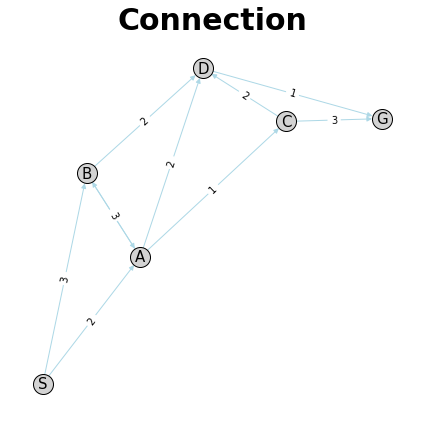

In [22]:
G = nx.DiGraph()
#aco-routingの設定をnetworkXの設定に移す
for i in graph.get_all_nodes():
    a = graph.get_node_edges(i)
    for j in a:
        G.add_edge(i, j, weight=round(a[j].travel_time,1))
#表示
pos = nx.spring_layout(G, seed=6)
fig, ax = plt.subplots(figsize=(6, 6))
font = {"fontname": "sans-serif", "color": "k", "fontweight": "bold", "fontsize": 30}
ax.set_title("Connection", font)
nx.draw_networkx(G, pos, font_size=15, node_size=400, font_family="sans-serif", edge_color="lightblue", node_color="lightgray",edgecolors="black")
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)
#nx.draw_networkx_edge_labels(G, pos, edge_labels)
#nx.draw_networkx( G, pos, with_labels=False, edgelist=edge_list, edge_color="red", node_color="lightgray", width=2)
fig.tight_layout()
plt.axis("off")
plt.savefig("Connection.pdf")
plt.show()

## 探索の実行（アントコロニー最適化）

アントコロニー最適化の実行

In [23]:
aco = ACO(graph)
path, cost = aco.find_shortest_path(source, destination)
print(f"ACO - path: {path}, cost: {cost}")

ACO - path: ['S', 'A', 'C', 'G'], cost: 6.0


## 結果の可視化（アントコロニー最適化）

経路をNetworkXで表示しやすくするための処理

In [24]:
edge_list = []
for i in range(len(path)-1):
    edge_list.append((path[i],path[i+1]))

NetworkXによる結果の表示

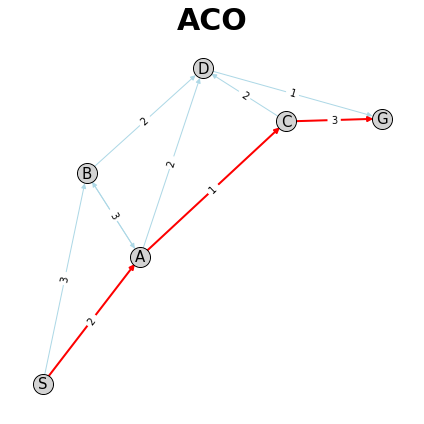

In [25]:
G = nx.DiGraph()

for i in graph.get_all_nodes():
    a = graph.get_node_edges(i)
    for j in a:
        G.add_edge(i, j, weight=round(a[j].travel_time,1))

#pos = nx.spring_layout(G, seed=6)#これを実行すると経由地の確認のグラフの形と違くなります．
fig, ax = plt.subplots(figsize=(6, 6))
font = {"fontname": "sans-serif", "color": "k", "fontweight": "bold", "fontsize": 30}
ax.set_title("ACO", font)
nx.draw_networkx(G, pos, font_size=15, node_size=400, font_family="sans-serif", edge_color="lightblue", node_color="lightgray",edgecolors="black")
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)
nx.draw_networkx( G, pos, with_labels=False, edgelist=edge_list, edge_color="red", node_color="lightgray", width=2)
fig.tight_layout()
plt.axis("off")
plt.savefig("ACO(distance).pdf")
plt.show()

## フェロモンの確認（アントコロニー最適化）

経路をNetworkXで表示しやすくするための処理

In [26]:
edge_list = []
for i in range(len(path)-1):
    edge_list.append((path[i],path[i+1]))

NetworkXによる結果の表示

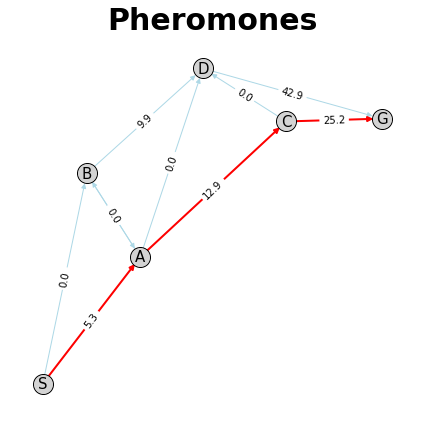

In [27]:
G = nx.DiGraph()

for i in graph.get_all_nodes():
    a = graph.get_node_edges(i)
    for j in a:
        G.add_edge(i, j, weight=round(a[j].pheromones,1))

#pos = nx.spring_layout(G, seed=6)#これを実行すると経由地の確認のグラフの形と違くなります．
fig, ax = plt.subplots(figsize=(6, 6))
font = {"fontname": "sans-serif", "color": "k", "fontweight": "bold", "fontsize": 30}
ax.set_title("Pheromones", font)
nx.draw_networkx(G, pos, font_size=15, node_size=400, font_family="sans-serif", edge_color="lightblue", node_color="lightgray",edgecolors="black")
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)
nx.draw_networkx( G, pos, with_labels=False, edgelist=edge_list, edge_color="red", node_color="lightgray", width=2)
fig.tight_layout()
plt.axis("off")
plt.savefig("ACO(Pheromones).pdf")#画像を保存する場合
plt.show()


## 探索の実行（ダイクストラ法）

ダイクストラ法の実行

In [13]:
dijkstra = Dijkstra(graph)
path, cost = dijkstra.find_shortest_path(source, destination)
print(f"Dijkstra - path: {path}, cost: {cost}")

Dijkstra - path: ['S', 'A', 'D', 'G'], cost: 5.0


## 結果の確認（ダイクストラ法）

経路をNetworkXで表示しやすくするための処理

In [14]:
edge_list = []
for i in range(len(path)-1):
    edge_list.append((path[i],path[i+1]))

NetworkXによる結果の表示

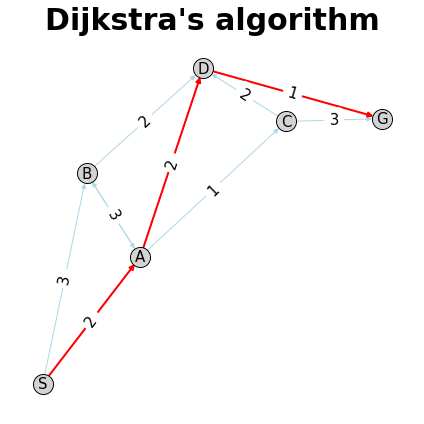

In [15]:
G = nx.DiGraph()

for i in graph.get_all_nodes():
    a = graph.get_node_edges(i)
    for j in a:
        G.add_edge(i, j, weight=round(a[j].travel_time,1))

#pos = nx.spring_layout(G, seed=6)#これを実行すると経由地の確認のグラフの形と違くなります．
fig, ax = plt.subplots(figsize=(6, 6))
font = {"fontname": "sans-serif", "color": "k", "fontweight": "bold", "fontsize": 30}
ax.set_title("Dijkstra's algorithm", font)
nx.draw_networkx(G, pos, font_size=15, node_size=400, font_family="sans-serif", edge_color="lightblue", node_color="lightgray",edgecolors="black")
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=15)
nx.draw_networkx( G, pos, with_labels=False, edgelist=edge_list, edge_color="red", node_color="lightgray", width=2)
fig.tight_layout()
plt.axis("off")
plt.savefig("Dijkstra's_algorithm(Distance).pdf")#画像を保存する場合
plt.show()

# 探索の実行（NetworkXのダイクストラ法）

In [16]:
G = nx.DiGraph()
#aco-routingの設定をnetworkXの設定に移す
for i in graph.get_all_nodes():
    a = graph.get_node_edges(i)
    for j in a:
        G.add_edge(i, j, weight=round(a[j].travel_time,1))

In [17]:
path = nx.dijkstra_path(G, source=source, target=destination)
cost = nx.dijkstra_path_length(G, source=source, target=destination)
print(f"Dijkstra by NetworkX - path: {path}, cost: {cost}")

Dijkstra by NetworkX - path: ['S', 'A', 'D', 'G'], cost: 5


## 結果の確認（NetworkXのダイクストラ法）

経路をNetworkXで表示しやすくするための処理

In [18]:
edge_list = []
for i in range(len(path)-1):
    edge_list.append((path[i],path[i+1]))

NetworkXによる結果の表示

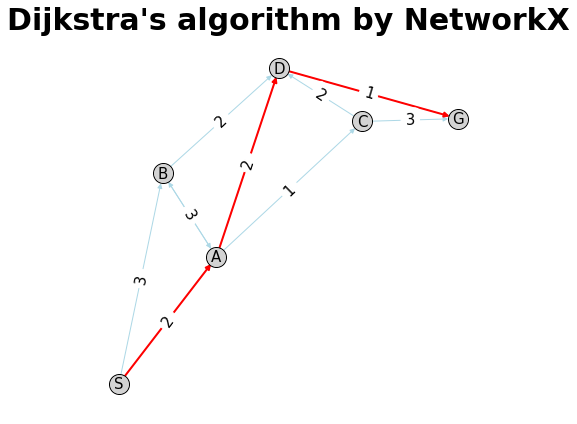

In [19]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()

for i in graph.get_all_nodes():
    a = graph.get_node_edges(i)
    for j in a:
        G.add_edge(i, j, weight=round(a[j].travel_time,1))

fig, ax = plt.subplots(figsize=(6, 6))
font = {"fontname": "sans-serif", "color": "k", "fontweight": "bold", "fontsize": 30}
ax.set_title("Dijkstra's algorithm by NetworkX", font)
pos = nx.spring_layout(G, seed=6)
nx.draw_networkx(G, pos, font_size=15, node_size=400, font_family="sans-serif", edge_color="lightblue", node_color="lightgray",edgecolors="black")
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=15)
nx.draw_networkx( G, pos, with_labels=False, edgelist=edge_list, edge_color="red", node_color="lightgray", width=2)
fig.tight_layout()
plt.axis("off")
plt.savefig("Dijkstra's_algorithm_by_Networkx(Distance).pdf")#画像を保存する場合
plt.show()